In [2]:
import os
import pandas as pd

# Define the folder path containing .dat files
folder_path = "./"

# Function to read and parse .dat files
def read_dat_file(file_path):
    with open(file_path, "r") as file:
        lines = file.readlines()

    # Find the start of the data section
    try:
        start_index = lines.index("[Curve Data]\n") + 2  # Data starts 2 lines after this
    except ValueError:
        print(f"Error: '[Curve Data]' not found in {file_path}")
        return pd.DataFrame()

    # Extract only relevant data lines (ignoring headers and empty lines)
    data = []
    for line in lines[start_index:]:
        line = line.strip()
        if not line or line.startswith("HeaderEnd"):  # Skip empty lines and 'HeaderEnd'
            continue
        parts = line.split(";")
        if len(parts) >= 4:  # Ensure at least 4 valid columns exist
            data.append(parts)

    # Convert to DataFrame
    columns = ["Session Time", "Volume (liters)", "Balloon Valve Status", "Patient Switch", "Gating Mode", "Gating Status", "Relay State"]
    df = pd.DataFrame(data, columns=columns)

    # Convert numerical columns to appropriate data types, ignoring errors
    df["Session Time"] = pd.to_numeric(df["Session Time"], errors="coerce")
    df["Volume (liters)"] = pd.to_numeric(df["Volume (liters)"], errors="coerce")
    df["Balloon Valve Status"] = pd.to_numeric(df["Balloon Valve Status"], errors="coerce")
    df["Patient Switch"] = pd.to_numeric(df["Patient Switch"], errors="coerce")

    # Drop rows where Session Time is NaN (which means those were header/invalid rows)
    df = df.dropna(subset=["Session Time"])

    return df

# Process all .dat files in the folder
dataframes = []
for file in os.listdir(folder_path):
    if file.endswith(".dat"):
        df = read_dat_file(os.path.join(folder_path, file))
        if not df.empty:
            dataframes.append(df)

# Combine all data into a single DataFrame
if dataframes:
    final_df = pd.concat(dataframes, ignore_index=True)
    print(final_df.head(50))  # Show first few rows
else:
    print("No valid data found in the .dat files.")


    Session Time  Volume (liters)  Balloon Valve Status  Patient Switch  \
0           0.02              0.0                     1               0   
1           0.04              0.0                     1               0   
2           0.06              0.0                     1               0   
3           0.08              0.0                     1               0   
4           0.10              0.0                     1               0   
5           0.12              0.0                     1               0   
6           0.14              0.0                     1               0   
7           0.16              0.0                     1               0   
8           0.18              0.0                     1               0   
9           0.20              0.0                     1               0   
10          0.22              0.0                     1               0   
11          0.24              0.0                     1               0   
12          0.26         

# Performing EDA

Total Manual Override Instances: 31052


C:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


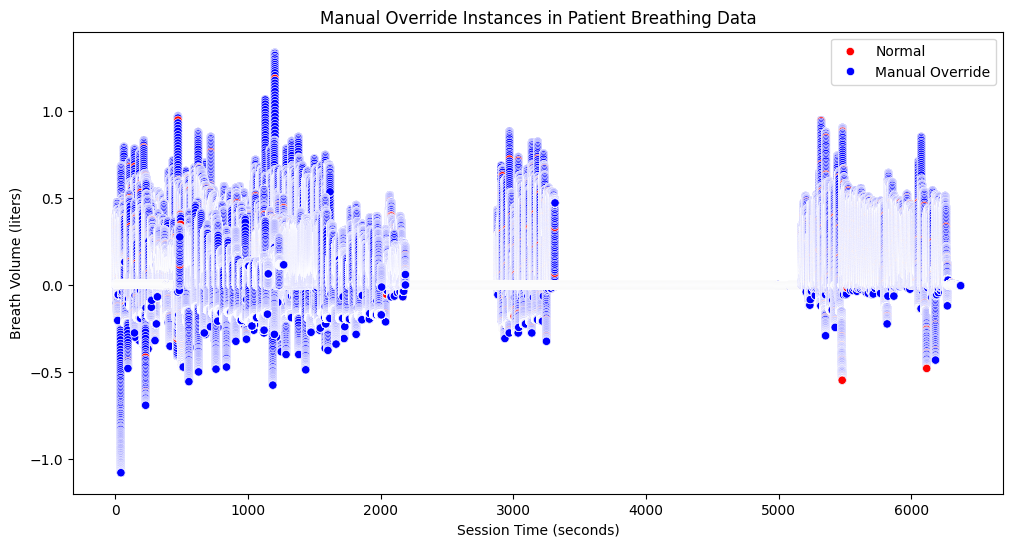

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
# Count occurrences of "Manual Override"
manual_override_counts = final_df["Gating Mode"].str.contains("Manual Overide", na=False).sum()

print(f"Total Manual Override Instances: {manual_override_counts}")

# Visualizing where manual overrides happened
plt.figure(figsize=(12, 6))
sns.scatterplot(x=final_df["Session Time"], y=final_df["Volume (liters)"], hue=final_df["Gating Mode"] == "Manual Overide", palette={True: "red", False: "blue"})
plt.xlabel("Session Time (seconds)")
plt.ylabel("Breath Volume (liters)")
plt.title("Manual Override Instances in Patient Breathing Data")
plt.legend(["Normal", "Manual Override"])
plt.show()


# Feature Engineering

In [4]:
# Detect inhale/exhale phases based on threshold 0.80 liters
final_df["Threshold Crossed"] = final_df["Volume (liters)"] > 0.80

# Count number of breathing cycles
final_df["Breathing Cycle"] = (final_df["Balloon Valve Status"] == 2).astype(int).cumsum()

print(final_df[["Session Time", "Volume (liters)", "Threshold Crossed", "Breathing Cycle"]].head(200))


     Session Time  Volume (liters)  Threshold Crossed  Breathing Cycle
0            0.02              0.0              False                0
1            0.04              0.0              False                0
2            0.06              0.0              False                0
3            0.08              0.0              False                0
4            0.10              0.0              False                0
..            ...              ...                ...              ...
195          3.92              0.0              False              120
196          3.94              0.0              False              121
197          3.96              0.0              False              122
198          3.98              0.0              False              123
199          4.00              0.0              False              124

[200 rows x 4 columns]


In [5]:
# Convert 'Gating Mode' column to ON (1) / OFF (0)
final_df["Gating Mode ON"] = final_df["Gating Mode"].apply(lambda x: 1 if x in ["Manual Override", "Automated"] else 0)


In [6]:
print(final_df["Gating Mode"].unique())  # Check all unique values
print(final_df["Gating Mode"].value_counts())  # Count each category


['Manual Overide' ' - ' 'Automated']
Gating Mode
 -                942627
Manual Overide     31052
Automated           9216
Name: count, dtype: int64


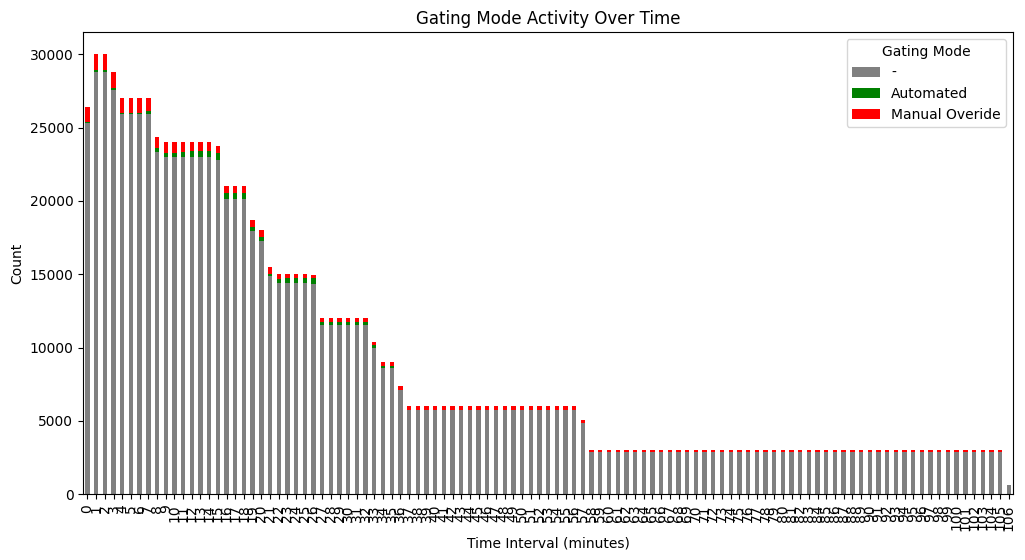

In [7]:
import matplotlib.pyplot as plt

# Ensure all keys match exactly
final_df["Gating Mode"] = final_df["Gating Mode"].replace(" - ", "-")  # Fix spacing issue

# Group data by time interval (per minute)
final_df["Time Interval"] = (final_df["Session Time"] // 60).astype(int)  

# Count occurrences in each interval
mode_trend = final_df.groupby(["Time Interval", "Gating Mode"]).size().unstack().fillna(0)

# Define a valid color dictionary with correctly formatted keys
color_dict = {
    "Manual Overide": "red",
    "Automated": "green",
    "-": "gray"  # Ensure it matches exactly
}

# Plot as grouped bar chart
mode_trend.plot(kind="bar", stacked=True, figsize=(12, 6), color=[color_dict.get(x, "gray") for x in mode_trend.columns])

plt.xlabel("Time Interval (minutes)")
plt.ylabel("Count")
plt.title("Gating Mode Activity Over Time")
plt.legend(title="Gating Mode")
plt.show()


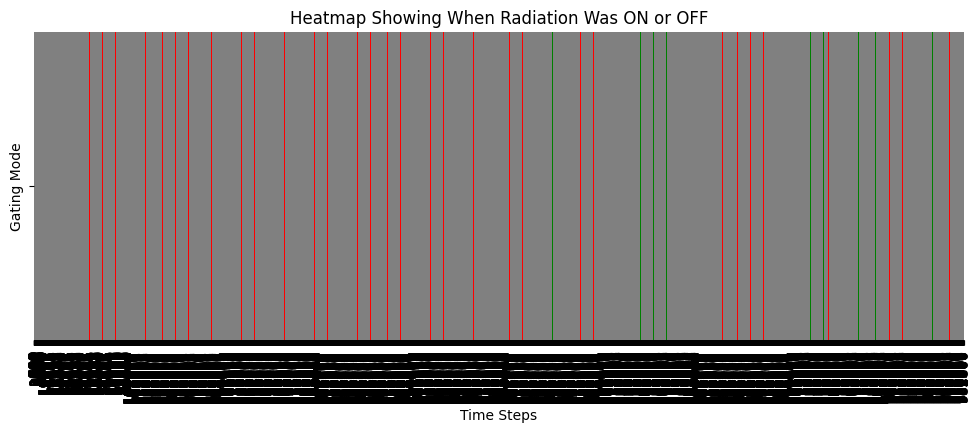

In [9]:
import numpy as np

plt.figure(figsize=(12, 4))

# Convert Gating Mode to numbers for heatmap
gating_map = {"Manual Overide": 2, "Automated": 1, "-": 0}
final_df["Gating Code"] = final_df["Gating Mode"].map(gating_map)

# Reshape into a 1-row array
gating_array = np.array(final_df["Gating Code"]).reshape(1, -1)

# Plot heatmap
sns.heatmap(gating_array, cmap=["gray", "green", "red"], cbar=False, xticklabels=100, yticklabels=["Gating Mode"])

plt.xlabel("Time Steps")
plt.title("Heatmap Showing When Radiation Was ON or OFF")
plt.show()


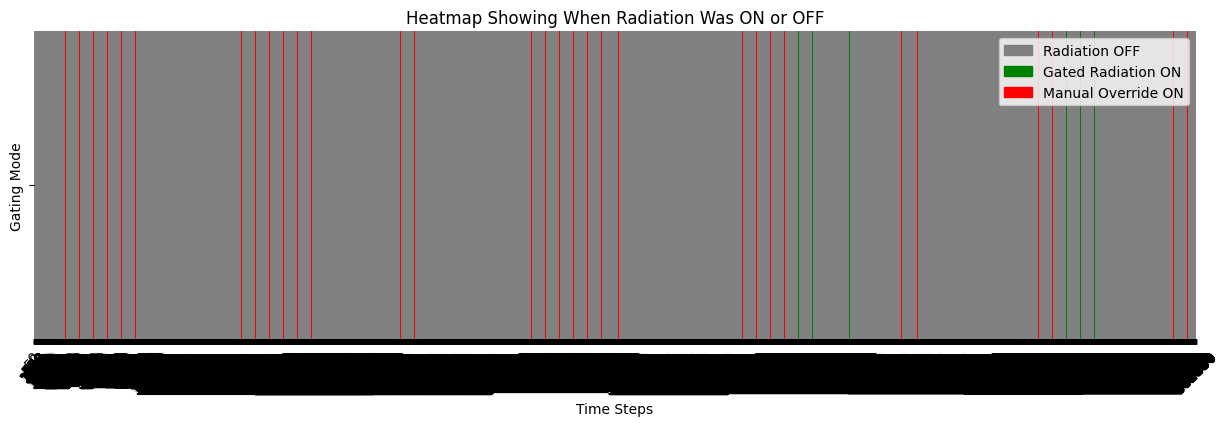

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Sample DataFrame (Replace with your actual data)
# final_df = pd.read_csv("your_data.csv")  # Uncomment if loading from a file

# Define the mapping for "Gating Mode"
gating_map = {"Manual Overide": 2, "Automated": 1, "-": 0}
final_df["Gating Code"] = final_df["Gating Mode"].map(gating_map)

# Convert to NumPy Array and Reshape for Heatmap
gating_array = np.array(final_df["Gating Code"]).reshape(1, -1)

# Create Figure
plt.figure(figsize=(15, 4))

# Heatmap with improved colors
sns.heatmap(
    gating_array,
    cmap=["gray", "green", "red"],  # OFF = Gray, Automated = Green, Manual = Red
    cbar=False,  # Hide color bar
    xticklabels=50,  # Show x-labels at intervals of 50
    yticklabels=["Gating Mode"]
)

# X-axis Label Formatting
plt.xlabel("Time Steps")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Title
plt.title("Heatmap Showing When Radiation Was ON or OFF")

# Add Legend
legend_labels = [
    Patch(color='gray', label='Radiation OFF'),
    Patch(color='green', label='Gated Radiation ON'),
    Patch(color='red', label='Manual Override ON')
]
plt.legend(handles=legend_labels, loc='upper right')

# Show Plot
plt.show()


ValueError: The number of FixedLocator locations (10), usually from a call to set_ticks, does not match the number of labels (11).

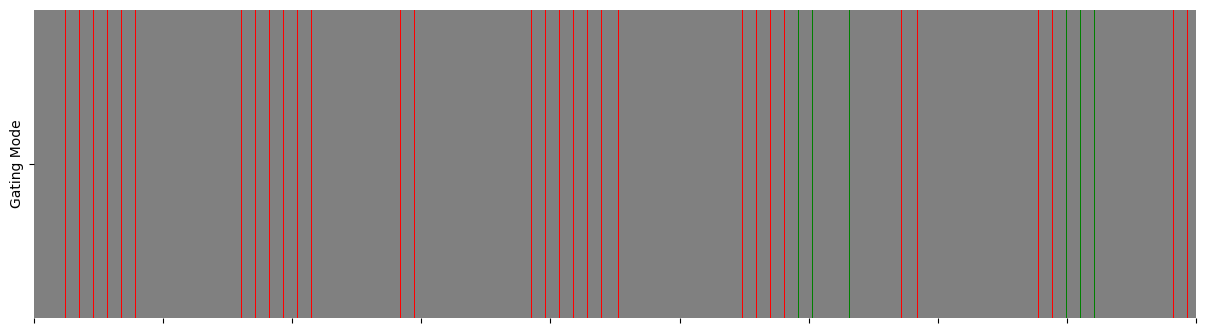

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Sample DataFrame (Replace with your actual data)
# final_df = pd.read_csv("your_data.csv")  # Uncomment if loading from a file

# Define the mapping for "Gating Mode"
gating_map = {"Manual Overide": 2, "Automated": 1, "-": 0}
final_df["Gating Code"] = final_df["Gating Mode"].map(gating_map)

# Convert to NumPy Array and Reshape for Heatmap
gating_array = np.array(final_df["Gating Code"]).reshape(1, -1)

# Create Figure
plt.figure(figsize=(15, 4))

# Heatmap with improved colors
sns.heatmap(
    gating_array,
    cmap=["gray", "green", "red"],  # OFF = Gray, Automated = Green, Manual = Red
    cbar=False,  # Hide color bar
    xticklabels=100,  # Show x-labels at intervals of 100
    yticklabels=["Gating Mode"]
)

# Fix x-axis labels
plt.xticks(
    ticks=np.linspace(0, len(final_df)-1, num=10),  # Spread 10 labels across
    labels=final_df.index[::len(final_df)//10],  # Show actual time values
    rotation=45
)

# X-axis Label
plt.xlabel("Time Steps")

# Title
plt.title("Heatmap Showing When Radiation Was ON or OFF")

# Add Legend
legend_labels = [
    Patch(color='gray', label='Radiation OFF'),
    Patch(color='green', label='Gated Radiation ON'),
    Patch(color='red', label='Manual Override ON')
]
plt.legend(handles=legend_labels, loc='upper right')

# Show Plot
plt.show()
